In [936]:
import copy
import random
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.distributions import Normal
from torch.distributions import Categorical

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import random

from data_handling import read_data, process_timestamp, get_min_since, transforms

In [937]:
plt.rcParams['figure.figsize'] = [20, 10]

In [938]:
use_cuda = torch.cuda.is_available()
device   = torch.device("cuda" if use_cuda else "cpu")

In [1026]:
data = read_data('FB')
min_since = get_min_since(data)
data_df = process_timestamp(data, min_since)



In [1027]:
data_df

,day_of_week,month,day,hour,min,data_pt_dex,min_since_open,open,high,low,close,volume
0,1,9,15,9,30,1,0.0,270.67,271.35,270.23,270.44,530819
1,1,9,15,9,31,2,1.0,270.44,270.77,269.89,270.07,92838
2,1,9,15,9,32,3,2.0,270.15,270.84,269.30,270.24,118802
3,1,9,15,9,33,4,3.0,270.36,270.43,269.70,270.28,80533
4,1,9,15,9,34,5,4.0,270.22,270.32,269.45,269.84,81969
...,...,...,...,...,...,...,...,...,...,...,...,...
12453,3,10,29,15,55,12454,385.0,282.09,282.09,281.46,281.58,140866
12454,3,10,29,15,56,12455,386.0,281.54,281.56,281.06,281.10,151069
12455,3,10,29,15,57,12456,387.0,281.12,281.85,281.10,281.83,204625
12456,3,10,29,15,58,12457,388.0,281.83,282.30,281.83,282.01,233385


In [1028]:
t = transforms(data_df)
t.all_transforms()
t.suplemental_factors()

In [1029]:
data_df = t.transformed

In [1030]:
test_shape = int(0.05*data_df.shape[0])
train_shape = data_df.shape[0] - test_shape

In [1031]:
train, test = data_df[:train_shape], data_df[train_shape:]

In [1032]:
#train

In [1033]:
#test

In [1034]:
data_df.shape

(12458, 18)

In [1035]:
a = [0, 1, 2]

In [1036]:
a[1:]

[1, 2]

In [1037]:
class build_datas():
    '''
    class to build out a dictionary with data for each ticker
    '''
    def __init__(self, tickers = []):
        '''
        input(s): list of tickers to retrieve data for 
        '''
        if tickers:
            self.tickers = tickers
        else:
            self.tickers = ['MSFT', 'AAPL', 'AMZN', 'FB', 'GOOG', 'TSLA']
            
        self.ticker_dic, self.mean_dic, self.var_dic = self.get_data()
            
    def get_data(self):
        '''
        retrieves and transforms data for each ticker
        '''
        all_ = {}
        all_mean = {}
        all_var = {}
        min_ = 1000000
        min_ticker = None
        
        sets = []
        
        for ticker in self.tickers:
            data = read_data(ticker)
            sets.append(set(list(data['Datetime'].values)))
            all_[ticker] = data
        
        common = sets[0]
        for set_ in sets[1:]:
            common = common & set_
        common = list(common)
        
        for ticker in self.tickers:
            df = all_[ticker]
            df = df[df['Datetime'].isin(common)]
            df = df.reset_index()
            
            min_since = get_min_since(df)
            df = process_timestamp(df, min_since)
            
            t = transforms(df)
            t.all_transforms()
            t.suplemental_factors()
            
            all_[ticker] = t.transformed
            all_mean[ticker] = t.scaler.mean_
            all_var[ticker] = t.scaler.var_
            
        return all_, all_mean, all_var


In [1038]:
bd = build_datas()

In [1039]:
def init_weights(m):
    '''
    weight intialization function 
    '''
    if isinstance(m, nn.Linear):
        nn.init.normal_(m.weight, mean=0., std=0.1)
        nn.init.constant_(m.bias, 0.1)

def base_net(state_dim, dim_1, dim_2, type_, drop_out):
    '''
    function to define base_network
    '''
    if type_ == 'linear':
        layers = [
            nn.Linear(state_dim, dim_1),
            nn.Tanh(),
            nn.Linear(dim_1, dim_2),
            nn.Tanh()
        ]
        if drop_out:
            layers.intsert(2, nn.Dropout(p = 0.3))
            layers.append(nn.Dropout(p = 0.3))
    else:
        print('not developed yet')
    
    return layers
    
        

In [1040]:
class actor(nn.Module):
    '''
    The actor class
    '''
    def __init__(self, state_dim, action_dim, type_ = 'linear', drop_out = False, discrete= True, std=0.0):
        '''
        input(s): dimensions of state and action, and the max action
        '''
        super(actor, self).__init__()
        
        ###for a discrete action space
        self.discrete = discrete
        
        self.log_std = nn.Parameter(torch.ones(1, action_dim) * std)
        
        self.set_params()
        
        self.set_up_layers(state_dim, action_dim, type_, drop_out)
        
        ###apply the intial weights if needed
        #self.apply(init_weights)
    
    def set_up_layers(self, state_dim, action_dim, type_, drop_out):
        '''
        make structure for the actor network
        '''

        layers = base_net(state_dim, self.dim_1, self.dim_2, type_, drop_out)
        layers.append(nn.Linear(self.dim_2, action_dim))
        
        self.model = nn.Sequential(*layers)
    
    def forward(self, state):
        '''
        forward propagate the network
        input(s): state
        output(s): result of the actor network
        '''
        out = self.model(state)
        if self.discrete:
            probs = F.softmax(out, dim = 1)
            return Categorical(probs)
        else: 
            mu  = self.model(state)
            std   = self.log_std.exp().expand_as(mu)
            dist  = Normal(mu, std)
            return dist
            
    def set_params(self, dim_1 = 64, dim_2 = 32):
        '''
        set the parameters for the number of neurons
        input(s): dims for neuron layers
        '''
        self.dim_1 = dim_1
        self.dim_2 = dim_2

In [1041]:
class critic(nn.Module):
    '''
    critic class
    '''
    def __init__(self, state_dim, type_ = 'linear', drop_out = False):
        '''
        input(s): dimensions of state and action
        '''
        super(critic, self).__init__()
        
        self.set_params()
        self.set_up_layers(state_dim, type_, drop_out)
        
        self.apply(init_weights)
    
    def set_up_layers(self, state_dim, type_ , drop_out):
        '''
        make structure for the actor network
        '''
        layers = base_net(state_dim, self.dim_1, self.dim_2, type_, drop_out)
        layers.append(nn.Linear(self.dim_2, 1))
        self.model = nn.Sequential(*layers)
    
    def forward(self, state):
        '''
        forward propagate the network
        input(s): state and action
        output(s): result of the critic network
        '''
        return self.model(state)
        
    def set_params(self, dim_1 = 64, dim_2 = 32):
        '''
        set the parameters for the number of neurons
        input(s): dims for neuron layers
        '''
        self.dim_1 = dim_1
        self.dim_2 = dim_2

In [1042]:
def compute_gae(next_value, rewards, values, gamma=0.99, tau=0.95):
    '''
    General Advantage Estimation function from paper: used to estimate the advatage the actor gains 
        from a particular action
    input(s):
    '''
    values = values + [next_value]
    gae = 0
    returns = []
    for step in reversed(range(len(rewards))):
        delta = rewards[step] + gamma * values[step + 1]  - values[step]
        gae = delta + gamma * tau * gae
        returns.insert(0, gae + values[step])
    return returns

In [1043]:
def ppo_iter(mini_batch_size, states, actions, log_probs, returns, advantage):
    '''
    iterate through a set of the data using minibatches
    input(s):
    '''
    batch_size = states.size(0)
    for _ in range(batch_size // mini_batch_size):
        rand_ids = np.random.randint(0, batch_size, mini_batch_size)
        #rand_ids = np.random.randint(0, batch_size - mini_batch_size)
        yield states[rand_ids, :], actions[rand_ids, :], log_probs[rand_ids, :], returns[rand_ids, :], advantage[rand_ids, :]
        #yield states[rand_ids:rand_ids+mini_batch_size:, :], actions[rand_ids:rand_ids+mini_batch_size, :], log_probs[rand_ids:rand_ids+mini_batch_size, :], returns[rand_ids:rand_ids+mini_batch_size, :], advantage[rand_ids:rand_ids+mini_batch_size, :]

In [1044]:
def ppo_update(ppo_epochs, mini_batch_size, states, actions, log_probs, returns, advantages, actor_, critic_, optimizer_actor, optimizer_critic, clip_param=0.2):
    '''
    training loop: iterate through batches of states, actions, returns and advantages 
    '''
    for _ in range(ppo_epochs):
        for state, action, old_log_probs, return_, advantage in ppo_iter(mini_batch_size, states, actions, log_probs, returns, advantages):
            ###obtain outputs from neural nets
            dist = actor_(state)
            value = critic_(state)
            
            ###calculate entropy and log_prob
            entropy = dist.entropy().mean()
            new_log_probs = dist.log_prob(action)
            
            ###calculate ppo ratio from paper
            ratio = (new_log_probs - old_log_probs).exp()
            surr1 = ratio * advantage
            surr2 = torch.clamp(ratio, 1.0 - clip_param, 1.0 + clip_param) * advantage
            
            ###actor and critic losses
            actor_loss  = - torch.min(surr1, surr2).mean() - 0.001 * entropy
            mse_loss = nn.MSELoss()
            critic_loss = mse_loss(value, return_) - 0.001 * entropy

            ###update
            optimizer_actor.zero_grad()
            optimizer_critic.zero_grad()
            

            actor_loss.backward(retain_graph=True)
            critic_loss.backward(retain_graph=True)
            
            optimizer_actor.step()
            optimizer_critic.step()

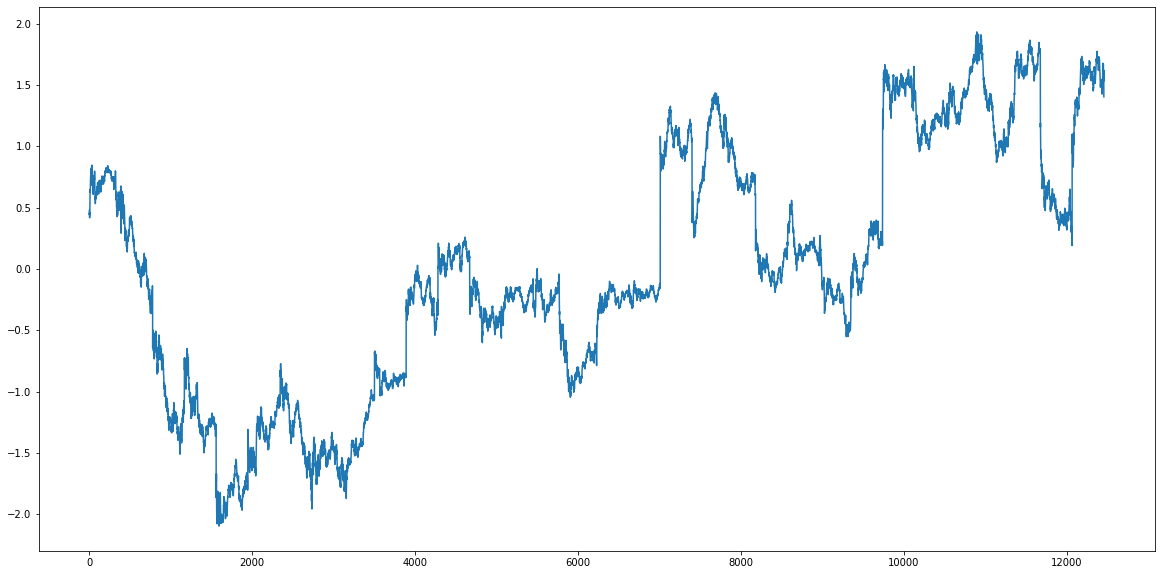

In [1045]:
plt.plot(data_df['close'])

In [1046]:
class synthetic_environment():
    '''
    build some synthetic data
    '''
    def __init__(self):
        
        self.action_dim = 2
        self.state_dim = 4
        self.n_pts = 50000
        self.data_df = self.build()
        self.sell_sigs = []
        self.buy_sigs = []
        self.monies_i = []
        self.monies_c = []

    def build(self):
        '''
        build out the data to look like sin
        output(s):
        '''
        x = 2*np.linspace(0, 100, self.n_pts)
        all_ = []
        def builder(x):
            y = np.sin(x) + np.sin(1.77*x) + np.sin(0.47*x) + np.cos(0.1*x) + 0.1*np.random.normal(size=self.n_pts)
            return y + 200
        for _ in range(self.state_dim):
            x = builder(x)
            mu = np.mean(x)
            std = np.std(x)
            all_.append((x - mu)/std)
        return pd.DataFrame(all_).T
        
    def initial_state(self, random = False):
        '''
        return an intial state, can be either random state or first state in the data
        
        input(s): random boolean if random intial state
        output(s): state vector
        '''
        if random:
            i = np.random.randint(0, int(self.data_length/2))
        else:
            i = 0
        self.initial_cash = 10000.0
        initial_investment = 0.0
        shares_outstanding = 0.0
        
        prelim_state = self.data_df.iloc[i].values.reshape(1, -1)
        state = np.append(prelim_state, [[initial_investment, shares_outstanding, self.initial_cash]], axis = 1)
        self.current_state = state
        return state
    
    def rewards(self, state):
        '''
        calculate the returns for given action 
        '''
        ###invested + penalty*cash - initial dollars
        penalty = 0.95
        return (state[:,-3].item() + penalty*(state[:,-1].item()) - self.initial_cash)
    
    def step(self, action, state, idx):
        '''
        take the next step based on the previous state and action choice
        
        input(s): current state, action to take
        output(s): next_state, reward
        '''
        #use low to update val of investment
        investment = state[:,0].item()*state[:,-2].item() 
        shares = state[:,-2].item()
        cash = state[:,-1].item()
        
        ###buy/sell action transition from invested to divested or vice versa
        if action == 0:
            #print('buy/sell')
            ###divest
            if cash == 0.0:

                shares = 0.0
                cash = investment
                investment = 0.0
                
                self.sell_sigs.append([idx, state[:,0].item()])
            ###invest    
            else:
                investment = cash
                shares = investment/state[:,1].item() #use high to calc buy
                cash = 0.0
                
                self.buy_sigs.append([idx, state[:,0].item()])
#         if action == 1:
#             cash = 0.999*cash
        
        self.monies_i.append(investment)
        self.monies_c.append(cash)
        
        prelim_state = self.data_df.iloc[idx].values.reshape(1, -1)
        state = np.append(prelim_state, [[investment, shares, cash]], axis = 1)
        
        return self.rewards(state), state
        
        
        
    

In [1047]:
envs = synthetic_environment()

In [1048]:
#plt.plot(envs.data_df[0])

In [1049]:
class environment():
    '''
    Class for defining the environment the agent interacts with
    '''
    def __init__(self, data_df, mean, var, action_dim = 2, discrete = True):
        '''
        input(s): data
        '''
        
        self.data_df = data_df
        self.mean = mean
        self.var = var
        self.discrete = discrete
        
        cols = list(self.data_df.columns)
        self.l_i = cols.index('low')
        self.h_i = cols.index('high')
        self.c_i = cols.index('close')
        
        #self.reward_type = 'excess_returns'
        #self.reward_type = 'excess_returns_simple'
        #self.reward_type = 'log_basic'
        self.reward_type = 'basic_trade_penalty'
        
        self.action_dim = action_dim
        self.state_dim = self.data_df.shape[1]
        self.data_length = self.data_df.shape[0]
        
        self.sell_sigs = []
        self.buy_sigs = []
        
        self.monies_i = [] 
        self.monies_c = []
        
        self.part_a = []
        self.part_b = []
        
        self.profits = []
        
        self.all_actions = []
        
        self.total_trades = []
        
        
    def initial_state(self, random = False):
        '''
        return an intial state, can be either random state or first state in the data
        
        input(s): random boolean if random intial state
        output(s): state vector
        '''
        if random:
            i = np.random.randint(0, int(0.75*self.data_length))
        else:
            i = 0
        self.initial_cash = 10000.0
        initial_investment = 0.0
        shares_outstanding = 0.0
        
        self.prev_cash = self.initial_cash
        
        num_trades = 0.0
        prelim_state = self.data_df.iloc[i].values.reshape(1, -1)
        running_trades = 3.0
        
        state = np.append(prelim_state, [[running_trades, num_trades, initial_investment, shares_outstanding, self.initial_cash]], axis = 1)
        self.initial_shares = self.initial_cash/state[:,self.h_i].item()
        return state, i
    
    def rewards(self, state, prev_cash, prev_investment, prev_close):
        '''
        calculate the returns for given action 
        '''
        ###invested + penalty*cash - initial dollars
        penalty = 1.0
        invested = state[:,-3].item()
        cash = state[:,-1].item()
        trades = state[:,-4].item()
        close = state[:,self.c_i].item()
        
        def log_clip(x):
            return np.log(np.clip(x, 1e-5, None))
        
#         print('invested {}'.format(invested))
#         print('prev_investment {}'.format(prev_investment))
#         print('cash {}'.format(cash))
#         print('prev_cash {}'.format(prev_cash))
        
        if self.reward_type == 'basic':
            r = invested + penalty*cash - self.initial_cash
        elif self.reward_type == 'basic_trade_penalty':
            r = invested + penalty*cash + trades*np.log((1 - 0.35)/(1+0.35))
        elif self.reward_type == 'excess_returns':
            #np.log(close/prev_close)
            sign = 1.0 #np.sign(close - prev_close)
            small_ = 1e-4
            part_a = sign*((log_clip(invested)-log_clip(prev_investment)) - (log_clip(cash) - log_clip(prev_cash))) - (log_clip(close*self.initial_shares) - log_clip(prev_close*self.initial_shares)) 
            part_b = trades*np.log((1 - 0.0025)/(1+0.0025))

            r = part_a + part_b
            self.part_a.append(part_a)
            self.part_b.append(part_b)
            
        elif self.reward_type == 'excess_returns_simple':
            small_ = 1e-4
            part_a = log_clip(invested+cash)-log_clip(prev_investment+prev_cash) - (log_clip(close*self.initial_shares) -log_clip(prev_close*self.initial_shares)) 
            part_b = trades*np.log((1 - 0.0025)/(1+0.0025))
            
            r = part_a + part_b
            
            self.part_a.append(part_a)
            self.part_b.append(part_b)
            
        elif self.reward_type == 'log_basic':
            small_ = 1e-4
            part_a = log_clip(invested+cash) - log_clip(close*self.initial_shares)
            part_b = trades*np.log((1 - 0.0025)/(1+0.0025))
            
            r = part_a + part_b
            
            self.part_a.append(part_a)
            self.part_b.append(part_b)
            
        return r
    
    def step(self, action, state, idx):
        ''' 
        take the next step based on the previous state and action choice
        
        input(s): current state, action to take
        output(s): next_state, reward
        '''
       
        #open:0 high:1 low:2 close:3 volume:4
        low = (state[:,self.l_i].item() + self.mean[2])*np.sqrt(self.var[2])
        high = (state[:,self.h_i].item() + self.mean[1])*np.sqrt(self.var[1])
        close = (state[:,self.c_i].item() + self.mean[3])*np.sqrt(self.var[3])
        
        #use low to update val of investment
        prev_investment = low*state[:,-2].item() 
        shares = state[:,-2].item()
        prev_cash = state[:,-1].item()
        trades = state[:,-4].item()
        running_trades = state[:,-5].item()
        
        if self.discrete:
            self.all_actions.append(action)
            ###buy/sell action transition from invested to divested or vice versa
            cash, shares, investment, trades = self.action_select(action, prev_cash, shares, prev_investment, trades, running_trades, high, close, idx)     
        else:
            self.all_actions.append([action[0], action[1]])
            cash, shares, investment, trades, running_trades = self.action_select_2(action, prev_cash, shares, prev_investment, trades, running_trades, high, close, low, idx) 

        self.monies_i.append(investment)
        self.monies_c.append(cash)
        self.total_trades.append(trades)
        
        prelim_state = self.data_df.iloc[idx].values.reshape(1, -1)
        state = np.append(prelim_state, [[running_trades, trades, investment, shares, cash]], axis = 1)
        
        return self.rewards(state, prev_cash, prev_investment, close), state
    
    def action_select(self, action, cash, shares, investment, trades, running_trades, high, close, idx):
        '''
        helper to select the action
        
        input(s): action value, the cash value, the number of shares, investment amount
        '''
        ###2 action dimensions
        if self.action_dim == 2:
            if action == 0:
                #print('buy/sell')
                ###divest
                if cash == 0.0:
                    shares = 0.0
                    cash += investment
                    investment = 0.0
                    
                    self.profits.append(cash - self.prev_cash)
                    self.prev_cash = cash
                    
                    self.sell_sigs.append([idx, close])
                    
                    trades += 1
                ###invest    
                else:
                    investment += cash
                    shares = investment/high #use high to calc buy
                    cash = 0.0
                    
                    self.buy_sigs.append([idx, close])
                    
                    trades += 1
        ###3 action dimensions
        elif self.action_dim == 3:
            ###divest
            if action == 0:
                
                #cash = 0.2*investment
                #investment = 0.8*investment
                #shares = investment/high
                if investment > 0:
                    cash += investment
                    investment = 0.0
                    shares = 0.0

                    self.sell_sigs.append([idx, close])
                    trades += 1
            
            elif action == 1:
                if cash > 0:
                    investment += cash
                    shares = investment/high #use high to calc buy
                    cash = 0.0

                    self.buy_sigs.append([idx, close])
                    trades += 1
            
            self.profits.append(cash+investment - self.prev_cash)
            self.prev_cash = cash+investment

        return cash, shares, investment, trades
    
    def action_select_2(self, action, cash, shares, investment, trades, running_trades, high, close, low, idx):
        '''
        helper to select the action
        
        input(s): action value, the cash value, the number of shares, investment amount
        '''
        #if self.action_dim == 2:
        #portion invested
        total = cash + investment

        new_investment = action[0]*total
        new_cash = action[1]*total

        diff_invest = new_investment - investment
        
        if running_trades >= 1.0:
            if np.abs(diff_invest) >= 0.25*investment:

                if diff_invest > 0:
                    shares += diff_invest/high
                    self.buy_sigs.append([idx, close])
                else:
                    shares += diff_invest/low
                    self.sell_sigs.append([idx, close])

                investment = new_investment
                cash = new_cash
                trades += 1
            running_trades -= 1

        running_trades += 0.05
        self.profits.append(investment + cash - self.prev_cash)
        self.prev_cash = investment + cash

        return cash, shares, investment, trades, running_trades
        

In [1050]:
class trainer_tester():
    '''
    class for implementing training/testing functionality
    '''
    def __init__(self, envs, discrete = True):
        ###make the environment
        self.envs = envs
        self.discrete = discrete
        
        ### intialize some hyper parameters
        self.state_dim = envs.state_dim + 5
        self.action_dim = envs.action_dim

        ###hyper params:
        self.lr               = 3e-4
        self.num_steps        = 300
        self.mini_batch_size  = 30
        self.ppo_epochs       = 6
        
        ###intialize actors and critics
        self.actor_ = actor(self.state_dim, self.action_dim, discrete=self.discrete)#.to(device)
        self.optimizer_actor = torch.optim.Adam(self.actor_.parameters(), lr = self.lr)

        self.critic_ = critic(self.state_dim)
        self.optimizer_critic = torch.optim.Adam(self.critic_.parameters(), lr = self.lr)
       

    def add_states(self, state, idx, entropy):
        '''
        add states to the batch of state, action, rewards ... etc pairs
        
        input(s): state-tensor with current state, current index in the data set, entropy-constant representing entropy
        '''
        state = torch.FloatTensor(state).to(device)
        
        dist = self.actor_(state)
        value = self.critic_(state)

        action = dist.sample()
        if self.discrete:
            temp = action.numpy().item()
        else:
            temp = F.softmax(action, dim = 1)
            temp = temp.numpy()[0]

        reward, next_state = self.envs.step(temp, state.numpy(), idx)

        log_prob = dist.log_prob(action)

        entropy += dist.entropy().mean()
        
        return log_prob.unsqueeze(1), value, torch.FloatTensor(np.array([reward])).unsqueeze(1), state, action.unsqueeze(1), next_state, entropy 

    
    def train(self, multiple_runs):
        torch.autograd.set_detect_anomaly(True)
        self.rewards_all = []
        for i in range(multiple_runs):
            if i == 0:
                state, j = self.envs.initial_state()
            else:
                state, j = self.envs.initial_state(random = True)
            max_idx = self.envs.data_df.shape[0] - j
            idx  = j + 1
            
            while idx < max_idx:
                log_probs = []
                values    = []
                states    = []
                actions   = []
                rewards   = []
                entropy = 0
                
                for _ in range(self.num_steps):

                    log_prob, value, reward, state, action, next_state, entropy = self.add_states(state, idx, entropy)
                    
                    log_probs.append(log_prob)
                    values.append(value)
                    rewards.append(reward)#.to(device))
                    states.append(state)
                    actions.append(action)

                    state = next_state
                    self.rewards_all.append(reward)
                    idx += 1
                    if idx >= max_idx:
                        break
                    
                    
                        
                next_state = torch.FloatTensor(next_state)#.to(device)
                next_value = self.critic_(next_state)
                returns = compute_gae(next_value, rewards, values)
                
                
                returns   = torch.cat(returns).detach()
                log_probs = torch.cat(log_probs).detach()
                values    = torch.cat(values).detach()
                states    = torch.cat(states)
                actions   = torch.cat(actions)
                advantage = returns - values
                
                
                ppo_update(self.ppo_epochs, self.mini_batch_size, states, actions, log_probs, returns, advantage, self.actor_, self.critic_, self.optimizer_actor, self.optimizer_critic)
                
    def test(self, envs):
        '''
        Implementation to test some of the data without updating any parameters of the networks
        '''
        self.envs = envs
        self.rewards_all_test = []
        state, j = self.envs.initial_state()
        max_idx = self.envs.data_df.shape[0] - j
        idx  = j + 1
        rewards_all = []
        entropy = 0
        while idx < max_idx:
            log_prob, value, reward, state, action, next_state, entropy = self.add_states(state, idx, entropy)
            state = next_state
            self.rewards_all_test.append(reward)
            idx += 1
            if idx >= max_idx:
                break
            
        
        

In [1077]:
class trainer_tester_multiple():
    '''
    class for implementing training/testing functionality
    '''
    def __init__(self, db, discrete = True, key = 'MSFT'):
        ###make the environment
        self.ticker_dic = db.ticker_dic
        self.mean_dic = db.mean_dic
        self.var_dic = db.var_dic
        self.discrete = discrete

        ###hyper params:
        self.lr               = 3e-4
        self.num_steps        = 300
        self.mini_batch_size  = 30
        self.ppo_epochs       = 3
        
        ###intialize actors and critics
        self.envs = environment(db.ticker_dic[key], db.mean_dic[key], db.var_dic[key], action_dim=2, discrete=False)
        
        ### intialize some hyper parameters
        self.state_dim = self.envs.state_dim + 5
        self.action_dim = self.envs.action_dim
        
        
        self.actor_ = actor(self.state_dim, self.action_dim, discrete=self.discrete)#.to(device)
        self.optimizer_actor = torch.optim.Adam(self.actor_.parameters(), lr = self.lr)

        self.critic_ = critic(self.state_dim)
        self.optimizer_critic = torch.optim.Adam(self.critic_.parameters(), lr = self.lr)
        
        ####set up lsit of actors, optimizers, envs
        self.actors_, self.actor_optimizers, self.envs_ = self.intialize_actors(db.ticker_dic, db.mean_dic, db.var_dic)
       
    def intialize_actors(self, ticker_dic, mean_dic, var_dic):
        '''
        intialize 1 or more actors 
        '''
        params_ = {'MSFT':3, 'AAPL' : 1, 'AMZN': 1, 'FB':1, 'GOOG':1, 'TSLA':1}
        
        actors_ = []
        actor_optimizers = []
        envs_ = []
        
        for key, val in params_.items():
            for _ in range(val):
                a = actor(self.state_dim, self.action_dim, discrete=self.discrete)
                a.load_state_dict(self.actor_.state_dict())
                actors_.append(a)
                actor_optimizers.append(torch.optim.Adam(a.parameters(), lr = self.lr))
                envs_.append(environment(ticker_dic[key], mean_dic[key], var_dic[key], action_dim=2, discrete=False))
        
        a = actors_
        b = actor_optimizers
        c = envs_
        
        d = list(zip(a, b, c))

        random.shuffle(d)
        actors_, actor_optimizers, envs_ = zip(*d)  
        
        self.n_workers = len(actors_)
        
        return actors_, actor_optimizers, envs_
            
    def add_states(self, actor_, envs, state, idx, entropy):
        '''
        add states to the batch of state, action, rewards ... etc pairs
        
        input(s): state-tensor with current state, current index in the data set, entropy-constant representing entropy
        '''
        state = torch.FloatTensor(state).to(device)
        
        dist = actor_(state)
        value = self.critic_(state)

        action = dist.sample()
        if self.discrete:
            temp = action.numpy().item()
        else:
            temp = F.softmax(action, dim = 1)
            temp = temp.numpy()[0]

        reward, next_state = envs.step(temp, state.numpy(), idx)

        log_prob = dist.log_prob(action)

        entropy += dist.entropy().mean()
        
        return log_prob.unsqueeze(1), value, torch.FloatTensor(np.array([reward])).unsqueeze(1), state, action.unsqueeze(1), next_state, entropy 

    
    def train(self):
        torch.autograd.set_detect_anomaly(True)
        self.rewards_all = []
        
        states_temp = [e.initial_state()[0] for e in self.envs_]
        max_idx = self.envs.data_df.shape[0] 
        idx  =  1
        
        counter = 1
        per = int(0.1*max_idx)
        
        state_main, _ = self.envs.initial_state()
        entropy_main = 0
        
        update_counter = 0
        
        while idx < max_idx:
            i = 0
            for actor_, optimizer, envs in zip(self.actors_, self.actor_optimizers, self.envs_):
                log_probs = []
                values    = []
                states    = []
                actions   = []
                rewards   = []
                entropy = 0
                
                state = states_temp[i]
                temp_idx = idx
                
                left_iterate = min(self.num_steps, max_idx - idx)
                
                
                for _ in range(left_iterate):
                    log_prob, value, reward, state, action, next_state, entropy = self.add_states(actor_, envs, state, temp_idx, entropy)

                    log_probs.append(log_prob)
                    values.append(value)
                    rewards.append(reward)#.to(device))
                    states.append(state)
                    actions.append(action)

                    state = next_state
                    
                    temp_idx += 1
                    

                next_state = torch.FloatTensor(next_state)#.to(device)
                next_value = self.critic_(next_state)
                returns = compute_gae(next_value, rewards, values)


                returns   = torch.cat(returns).detach()
                log_probs = torch.cat(log_probs).detach()
                values    = torch.cat(values).detach()
                states    = torch.cat(states)
                actions   = torch.cat(actions)
                advantage = returns - values


                ppo_update(self.ppo_epochs, self.mini_batch_size, states, actions, log_probs, returns, advantage, actor_, self.critic_, optimizer, self.optimizer_critic)
                
                states_temp[i] = state
                i += 1
                
                self.gradient_push(actor_)
            
            left_iterate = min(self.num_steps, max_idx - idx)
            temp_idx = idx
            
            with torch.no_grad():
                for _ in range(left_iterate): 
                    _, _, reward, state_main, _, next_state_main, entropy_main = self.add_states(self.actor_, self.envs, state_main, temp_idx, entropy_main)
                    state_main = next_state_main
                    self.rewards_all.append(reward)
                    
                    temp_idx += 1
                      
            idx += left_iterate
            update_counter += 1
                
            if update_counter%1 == 0:
                print('pushing network update')
                self.push_network_update()
            
            if update_counter % 3 == 0:
                print('{} % done.'.format((idx/max_idx)*100))
                 
            
    def gradient_push(self, actor_):
        '''
        push gradients to the main actor_
        '''
        self.optimizer_actor.zero_grad()
        for params, main_params in zip(actor_.parameters(), self.actor_.parameters()):
            main_params.grad = params.grad.clone()
        self.optimizer_actor.step()
        
    def push_network_update(self):
        '''
        after n iterations push the main network parameters to all exploring actors
        '''
        for actor_ in self.actors_:
            actor_.load_state_dict(self.actor_.state_dict())
    
    def baseline(self, envs):
        '''
        basline function for if trading were conducted with a random network
        '''
        state, _ = envs.initial_state()
        max_idx = self.envs.data_df.shape[0] 
        idx = 1
        self.rewards_all_test = []
        entropy = 0
        while idx < max_idx:
            actor_ = actor(self.state_dim, self.action_dim, discrete=self.discrete)
            log_prob, value, reward, state, action, next_state, entropy = self.add_states(actor_, envs, state, idx, entropy)
            state = next_state
            self.rewards_all_test.append(reward)
            idx += 1
            
            if idx % 100 == 0:
                print('{}% done.'.format((idx/max_idx)*100))
                
            if idx >= max_idx:
                break
                    
    def test(self, envs):
        '''
        Implementation to test some of the data without updating any parameters of the networks
        '''
        self.envs = envs
        self.rewards_all_test = []
        state, j = envs.initial_state()
        max_idx = envs.data_df.shape[0] - j
        idx  = j + 1
        rewards_all = []
        entropy = 0
        while idx < max_idx:
            log_prob, value, reward, state, action, next_state, entropy = self.add_states(state, idx, entropy)
            state = next_state
            self.rewards_all_test.append(reward)
            idx += 1
            if idx >= max_idx:
                break
            

In [1052]:
envs = environment(train, t.scaler.mean_, t.scaler.var_, action_dim=2, discrete=False)

In [1053]:
trainer = trainer_tester(envs, discrete=False)

In [1054]:
trainer.train(1)

In [1055]:
envs_test = environment(test, t.scaler.mean_, t.scaler.var_, action_dim=2, discrete=False)

In [1056]:
trainer.test(envs_test)

In [1078]:
multi_t = trainer_tester_multiple(bd, discrete = False)

In [1079]:
envs_baseline = environment(data_df, t.scaler.mean_, t.scaler.var_, action_dim=2, discrete=False)

In [1080]:
multi_t.baseline(envs_baseline)

0.8167265599477294% done.
1.6334531198954587% done.
2.4501796798431887% done.
3.2669062397909174% done.
4.0836327997386475% done.
4.9003593596863775% done.
5.717085919634107% done.
6.533812479581835% done.
7.350539039529566% done.
8.167265599477295% done.
8.983992159425025% done.
9.800718719372755% done.
10.617445279320483% done.
11.434171839268213% done.
12.250898399215943% done.
13.06762495916367% done.
13.884351519111402% done.
14.701078079059132% done.
15.51780463900686% done.
16.33453119895459% done.
17.151257758902318% done.
17.96798431885005% done.
18.784710878797778% done.
19.60143743874551% done.
20.418163998693238% done.
21.234890558640966% done.
22.051617118588695% done.
22.868343678536426% done.
23.685070238484155% done.
24.501796798431887% done.
25.318523358379615% done.
26.13524991832734% done.
26.951976478275075% done.
27.768703038222803% done.
28.58542959817053% done.
29.402156158118263% done.
30.21888271806599% done.
31.03560927801372% done.
31.852335837961448% done.
3

In [1081]:
multi_t.train()

pushing network update
pushing network update
pushing network update
7.358706305129043 % done.
pushing network update
pushing network update
pushing network update
14.709245344658608 % done.
pushing network update
pushing network update
pushing network update
22.059784384188173 % done.
pushing network update
pushing network update
pushing network update
29.410323423717738 % done.
pushing network update
pushing network update
pushing network update
36.76086246324731 % done.
pushing network update
pushing network update
pushing network update
44.11140150277687 % done.
pushing network update
pushing network update
pushing network update
51.461940542306436 % done.
pushing network update
pushing network update
pushing network update
58.812479581835994 % done.
pushing network update
pushing network update
pushing network update
66.16301862136557 % done.
pushing network update
pushing network update
pushing network update
73.51355766089513 % done.
pushing network update
pushing network update

In [1083]:
#trainer.rewards_all

In [1084]:
class plotter():
    def __init__(self, trainer, envs, envs_test):
        self.trainer = trainer
        self.envs = envs
        self.envs_test = envs_test
    
    def plot_rewards(self, test = False):
        if test:
            y = self.trainer.rewards_all_test
        else:
            y = self.trainer.rewards_all
            
        plt.plot(y)
        plt.title('rewards')
        plt.show()
    
    def plot_signals(self, test = False):
        if test:
            envs = self.envs_test
        else:
            envs = self.envs
            
        s = np.array(envs.sell_sigs)
        b = np.array(envs.buy_sigs)
        x = [i+1 for i in range(envs.data_df.shape[0])]
        y = (envs.data_df['close'] + envs.mean[3])*np.sqrt(envs.var[3])
        
        fig, ax = plt.subplots()
        ax.plot(x, y, label = 'close',color = 'black', alpha = 0.3)
        ax.scatter(s[:,0], s[:,1], label = 'sell signals', color = 'red', s = 35, alpha = 0.75, marker = '^')
        ax.scatter(b[:,0], b[:,1], label = 'buy signals', s =35, alpha = 0.35, marker = 'v')

        ax.legend()
        plt.show()
        
    def plot_monies(self, test = False):
        if test:
            envs = self.envs_test
        else:
            envs = self.envs
            
        c = np.array(envs.monies_c) 
        i = np.array(envs.monies_i)
        y = c+i
        
        plt.plot(y)
        plt.title('monies')
        plt.show()
        
    def plot_profits(self, test = False):
        if test:
            envs = self.envs_test
        else:
            envs = self.envs
        
        plt.plot(envs.profits)
        plt.title('per trade profits')
        plt.show()
    
    def plot_hist_trade_diff(self, test = False):
        if test:
            envs = self.envs_test
        else:
            envs = self.envs
        
        s = np.array(envs.sell_sigs)
        b = np.array(envs.buy_sigs)
        y = s[:,1].flatten() - b[:,1].flatten()[:s[:,1].shape[0]]
        
        plt.hist(y, bins = 30)
        plt.title('trade differential')
        plt.show()
        
    def plot_actions(self, test = False, discrete = False):
        if test:
            envs = self.envs_test
        else:
            envs = self.envs
        
        actions = np.array(envs.all_actions)
        
        plt.scatter([i+1 for i in range(actions.shape[0])], actions[:,1], label = 'cash', alpha = 0.5)
        plt.scatter([i+1 for i in range(actions.shape[0])], actions[:,0], label = 'investment', alpha = 0.5)
        plt.title('actions_taken')
        plt.show()
    
    def plot_trades(self, test = False):
        if test:
            envs = self.envs_test
        else:
            envs = self.envs
            
        plt.plot(envs.total_trades)
        plt.title('trades')
        plt.show()
        
    def plot_comparison(self, test = False):
        if test:
            envs = self.envs_test
        else:
            envs = self.envs
        
        fig, ax = plt.subplots()
        x = [i+1 for i in range(len(envs.part_a))]
        ax.scatter(x, envs.part_a, label = 'investment part')
        ax.scatter(x, envs.part_b, label = 'trade part')
        ax.legend()
        ax.set_title('portion of rewards')
        plt.show()

In [1090]:
p = plotter(multi_t, multi_t.envs, envs_baseline)
#p = plotter(trainer, envs, envs_test)

In [1091]:
#p = plotter(multi_t, multi_t.envs, None)

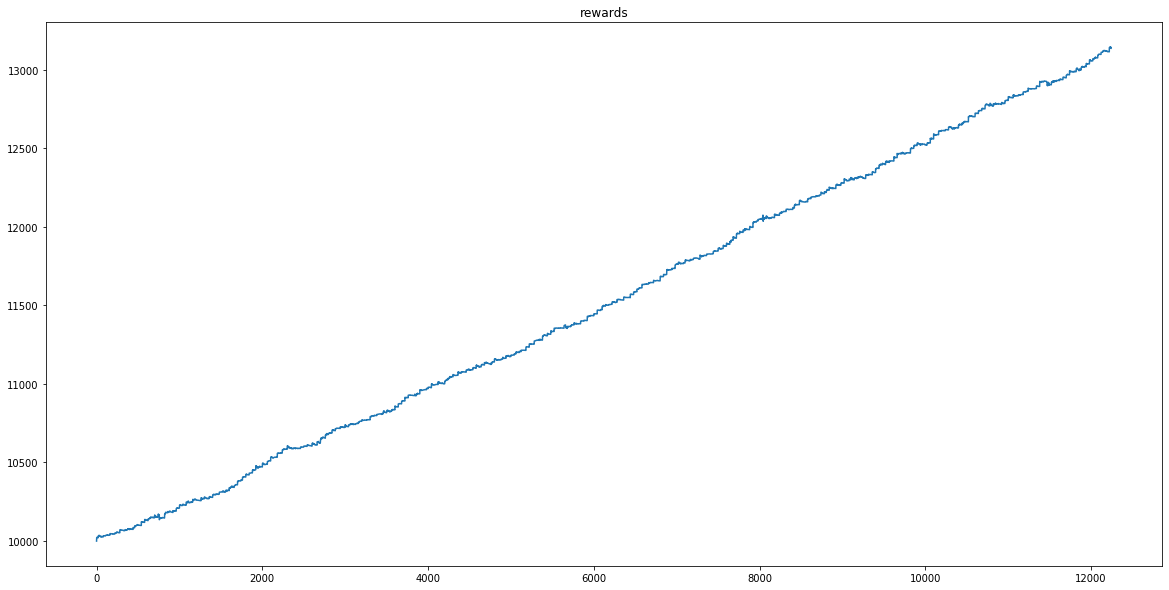

In [1092]:
p.plot_rewards()

In [1093]:
#p.plot_rewards(test = True)

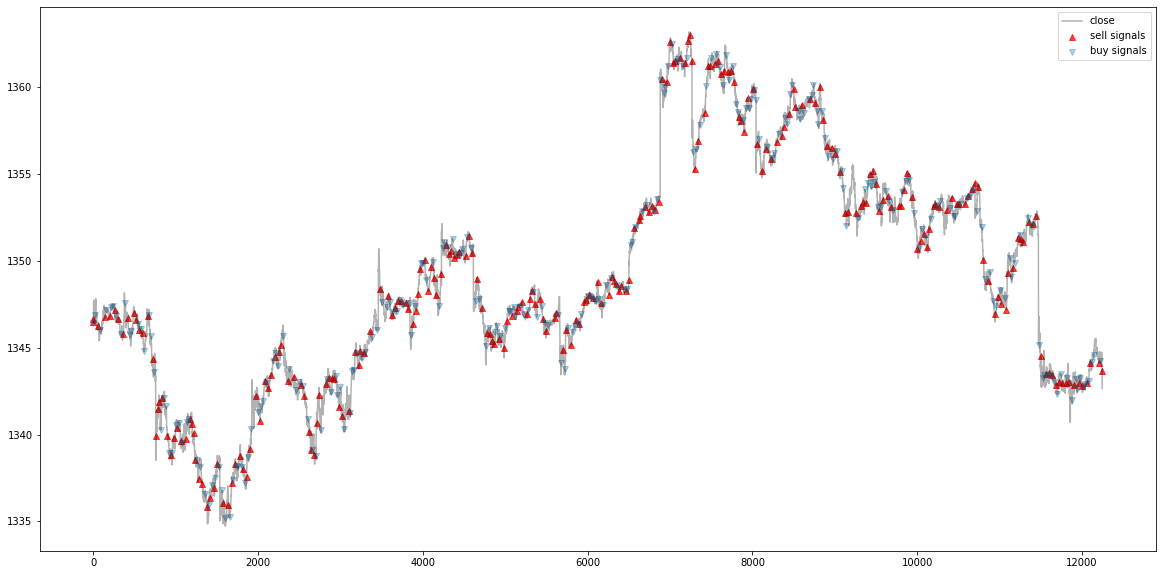

In [1094]:
p.plot_signals()

In [1095]:
#p.plot_signals(test = True)

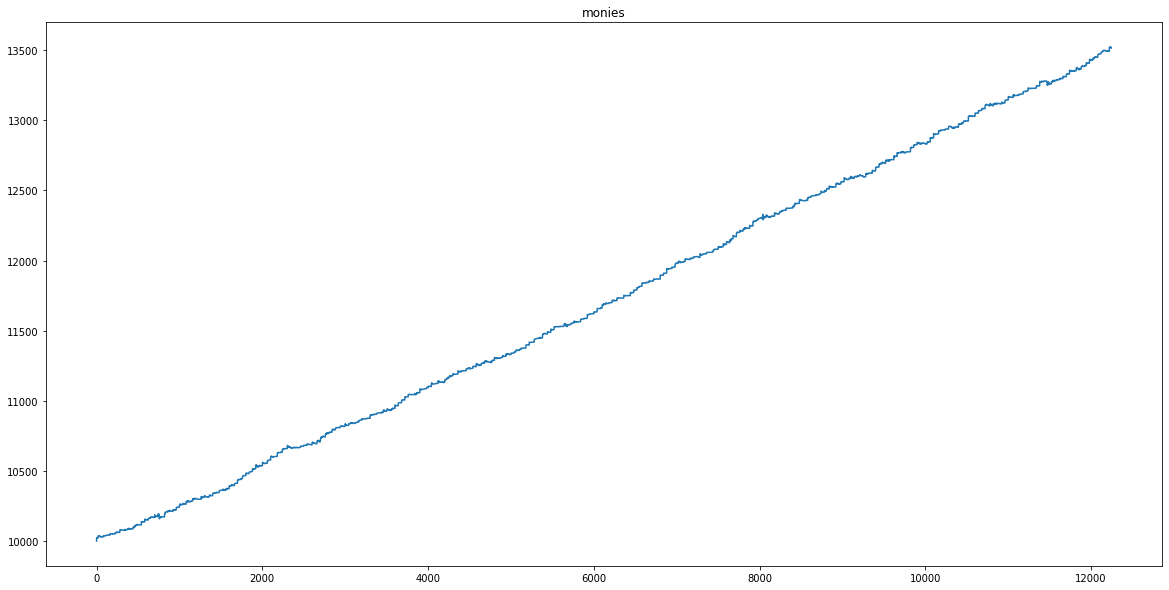

In [1096]:
p.plot_monies()

In [1097]:
#p.plot_monies(test = True)

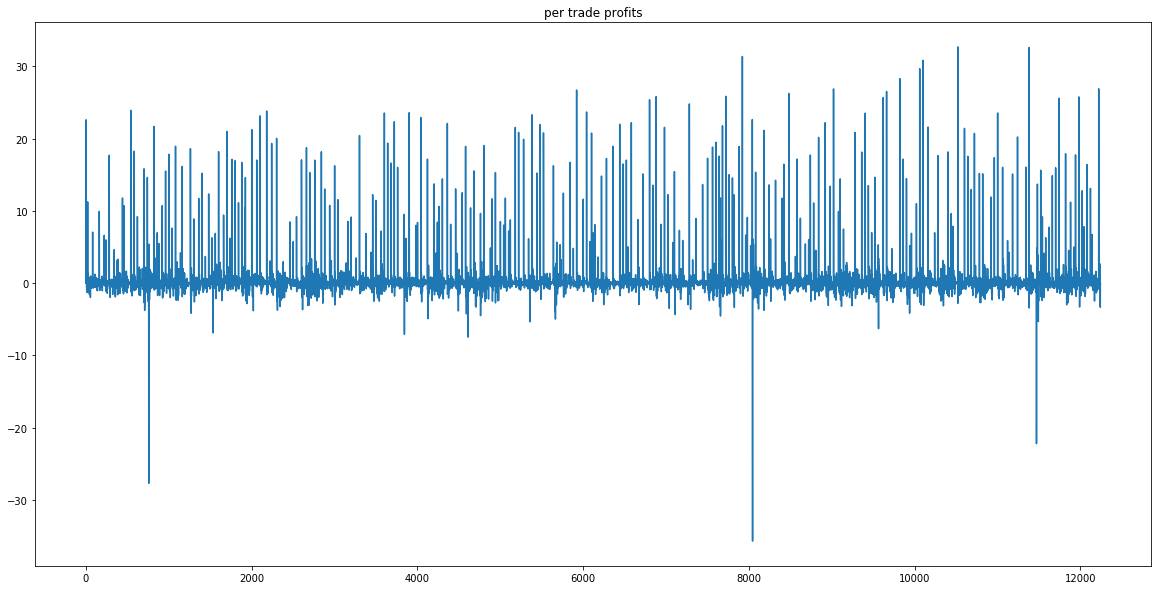

In [1098]:
p.plot_profits()

In [1099]:
#p.plot_profits(test = True)

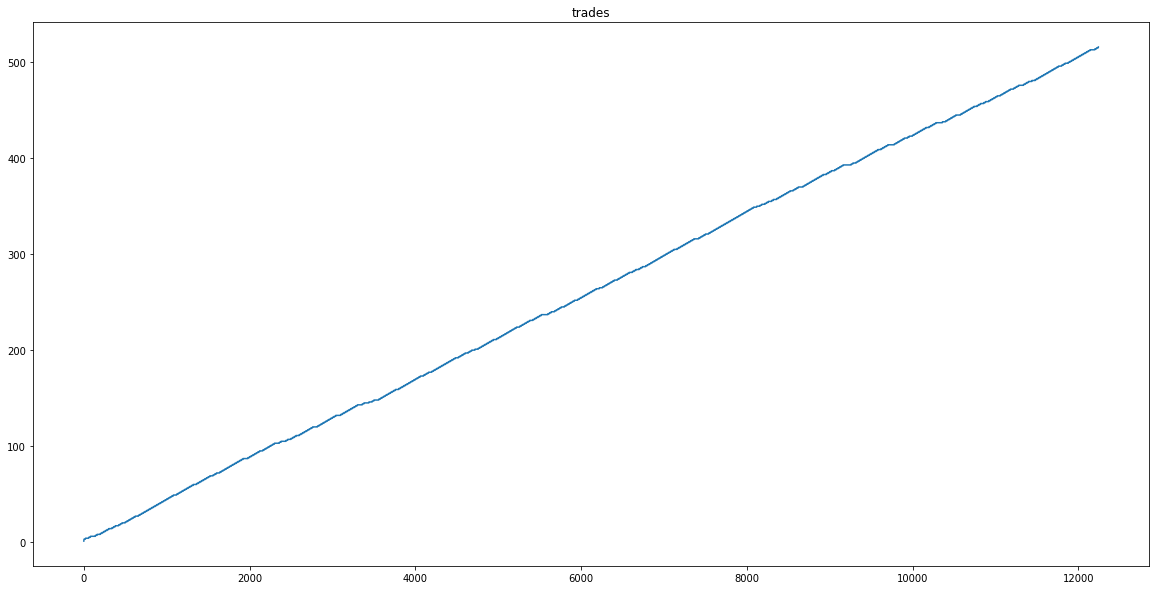

In [1100]:
p.plot_trades()

In [1101]:
#p.plot_trades(test = True)

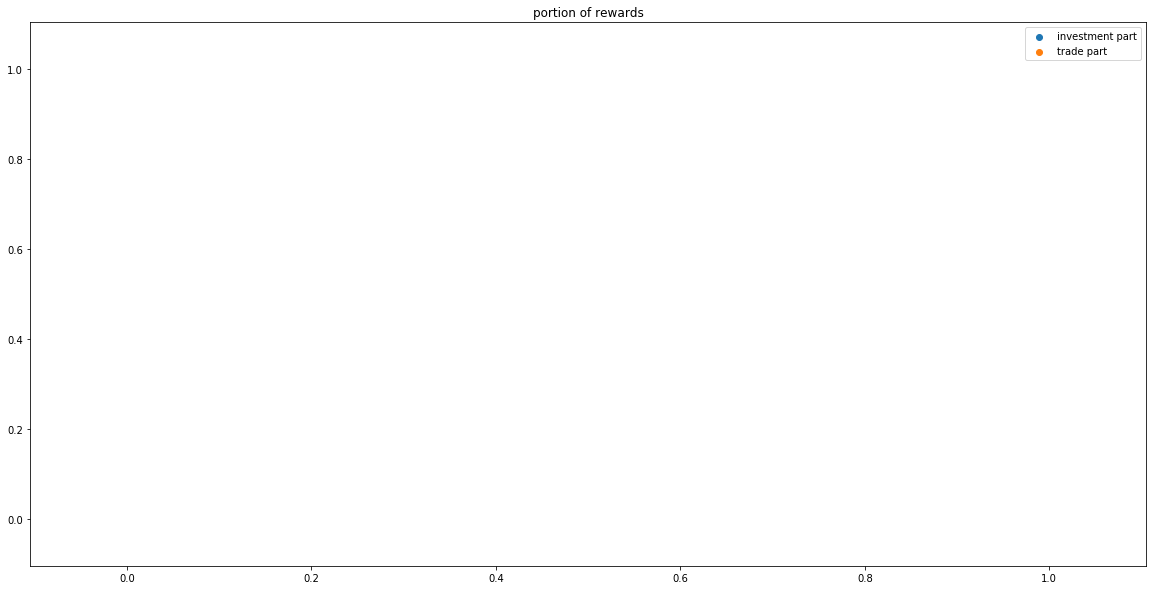

In [1102]:
p.plot_comparison()

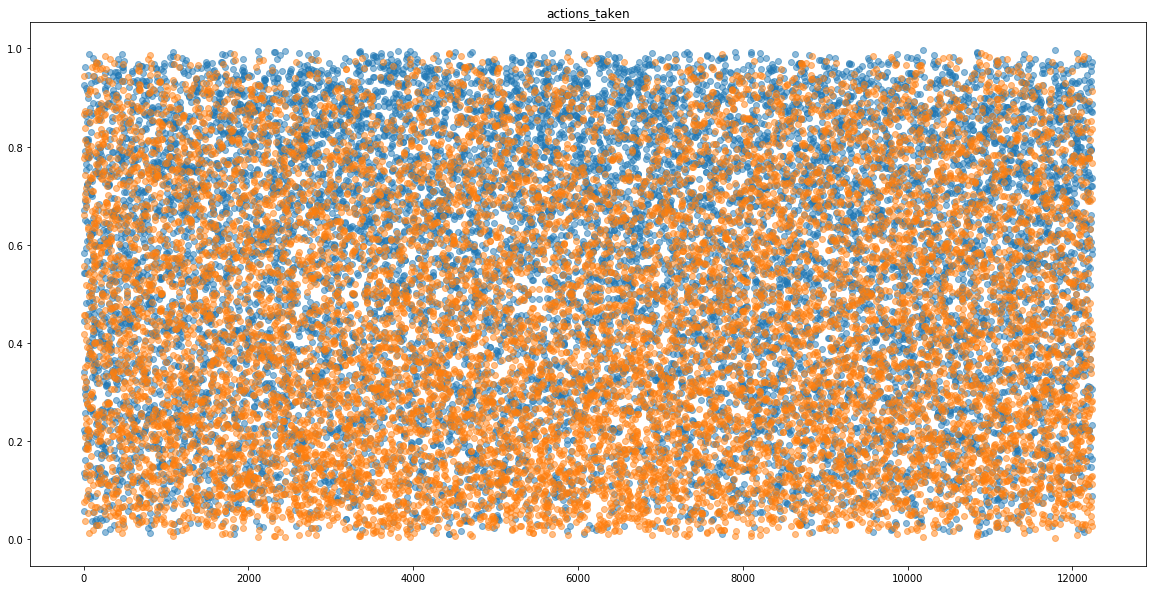

In [1103]:
p.plot_actions()

In [1104]:
#p.plot_hist_trade_diff()

In [138]:
#p.plot_hist_trade_diff(test = True)

In [62]:
# envs = environment(train, t.scaler.mean_, t.scaler.var_, action_dim=2)
# #envs = synthetic_environment()

# state_dim = envs.state_dim + 4
# action_dim = envs.action_dim

# ###hyper params:
# lr               = 3e-4
# num_steps        = 300
# mini_batch_size  = 30
# ppo_epochs       = 6
# threshold_reward = -200

# actor_ = actor(state_dim, action_dim)#.to(device)
# optimizer_actor = torch.optim.Adam(actor_.parameters(), lr = lr)

# critic_ = critic(state_dim)
# optimizer_critic = torch.optim.Adam(critic_.parameters(), lr = lr)

# max_idx = envs.data_df.shape[0]
# idx  = 1
# test_rewards = []

In [170]:
# torch.autograd.set_detect_anomaly(True)
# state = envs.initial_state()
# early_stop = False
# rewards_all = []
# while idx < max_idx and not early_stop:

#     log_probs = []
#     values    = []
#     states    = []
#     actions   = []
#     rewards   = []
#     entropy = 0
    
# #     actor_.eval()
# #     critic_.eval()
#     for _ in range(num_steps):
#         state = torch.FloatTensor(state).to(device)
        
#         dist = actor_(state)
#         value = critic_(state)
        
#         action = dist.sample()
        
#         reward, next_state = envs.step(action.numpy().item(), state.numpy(), idx)

#         log_prob = dist.log_prob(action)
        
#         entropy += dist.entropy().mean()
        
#         log_probs.append(log_prob.unsqueeze(1))
#         values.append(value)
#         rewards.append(torch.FloatTensor(np.array([reward])).unsqueeze(1))#.to(device))
        

#         states.append(state)
#         actions.append(action.unsqueeze(1))
        
#         state = next_state
#         idx += 1
#         if idx >= max_idx:
#             break
        
        
#     rewards_all.append(reward)
# #     actor_.train()
#     next_state = torch.FloatTensor(next_state)#.to(device)
#     next_value = critic_(next_state)
#     returns = compute_gae(next_value, rewards, values)
    
# #     critic_.train()
    
#     returns   = torch.cat(returns).detach()
#     log_probs = torch.cat(log_probs).detach()
#     values    = torch.cat(values).detach()
#     states    = torch.cat(states)
#     actions   = torch.cat(actions)
#     advantage = returns - values
    
#     if idx % 100 == 0:
#         #test_reward = np.mean([test_env() for _ in range(10)])
#         #test_rewards.append(test_reward)
#         plt.plot(rewards)
#         plt.show()
#         #if test_reward > threshold_reward: early_stop = True
    
#     ppo_update(ppo_epochs, mini_batch_size, states, actions, log_probs, returns, advantage)